# `ExponentialScheduler`

This notebook provides an empirical demonstration of the expected behavior of an `ExponentialScheduler`. Its purpose is to make the module's scheduling behavior observable in a simple setting in which it can be studied in isolation, rather than to exhaustively validate every implementation detail.

The capability examined is exponential scheduling across depth. An `ExponentialScheduler` changes its value exponentially as depth increases, while respecting the configured lower and upper bounds.

## Conceptual Overview

An `ExponentialScheduler` defines an exponential relationship between depth and scheduled value. For a scale $a$, rate $r$, and intercept $b$, the unconstrained value at depth $d$ is

$$
S(d)=ae^{rd}+b.
$$

The scale determines the magnitude of the exponential component, the rate controls how quickly it changes with depth, and the intercept shifts the resulting relationship vertically. The configured minimum and maximum values bound the schedule within the permitted range.

### Scope of the demonstration

The experiment evaluates an `ExponentialScheduler` over a finite range of depths and visualizes the resulting schedule.

In [1]:
import matplotlib.pyplot as plt

from jacinta.utils.schedulers import ExponentialScheduler

## Configuration

The parameters below are chosen to make the relevant behavior visible, but they should not be interpreted as general-purpose defaults.

`SCALE = 52` defines the magnitude of the exponential component.

`RATE = 0.0003` determines how quickly the scheduled value grows as depth increases.

`INTERCEPT = -52` shifts the exponential relationship vertically so that the schedule begins at zero.

`MIN_VALUE = 0` and `MAX_VALUE = 1000` define the lower and upper bounds of the schedule.

`MAX_DEPTH = 10000` determines the range over which the schedule is visualized. It does not affect the scheduler itself.

In [2]:
# hyperparameters
SCALE = 52
RATE = 0.0003
INTERCEPT = -52
MIN_VALUE = 0
MAX_VALUE = 1000

# plot parameters
MAX_DEPTH = 10000

## Visualization Utilities

The `ExponentialScheduler` can be evaluated directly at a requested depth. The following helper exposes that mapping for visualization.

`plot_scheduler()` evaluates the scheduler at every depth from zero through `MAX_DEPTH` and plots the resulting schedule. This provides a direct view of its behavior across the displayed range.

In [3]:
def plot_scheduler(
    ax: plt.Axes,
    scheduler: ExponentialScheduler,
) -> None:
    """
    Plot a scheduler.

    Args:
        ax (plt.Axes): The axes to plot on.
        scheduler (ExponentialScheduler): The scheduler to plot.
    """
    # evaluate the scheduler
    depths = list(range(MAX_DEPTH + 1))
    values = [scheduler(depth) for depth in depths]
    # plot the scheduler
    ax.plot(depths, values)
    ax.set_xlim(0, MAX_DEPTH)
    ax.set_xlabel("Depth")
    ax.set_ylabel("Value")
    ax.set_title(
        f"Exponential Scheduler "
        f"(scale={SCALE}, rate={RATE}, intercept={INTERCEPT}, "
        f"min_value={MIN_VALUE}, max_value={MAX_VALUE})"
    )
    ax.grid(visible=True, alpha=0.3)
    return

## Evaluation

The plot shows the scheduled value increasing from `0` at depth `0` to approximately `992.45` at depth `10000`. The increase is initially gradual and becomes progressively steeper as depth grows, reflecting an increasing rate of change throughout the displayed range.

The curved trajectory confirms that equal increases in depth produce increasingly larger changes in the scheduled value while the schedule remains within its configured bounds.

In [4]:
# initialize an ExponentialScheduler
scheduler = ExponentialScheduler(
    scale=SCALE,
    rate=RATE,
    intercept=INTERCEPT,
    min_value=MIN_VALUE,
    max_value=MAX_VALUE,
)

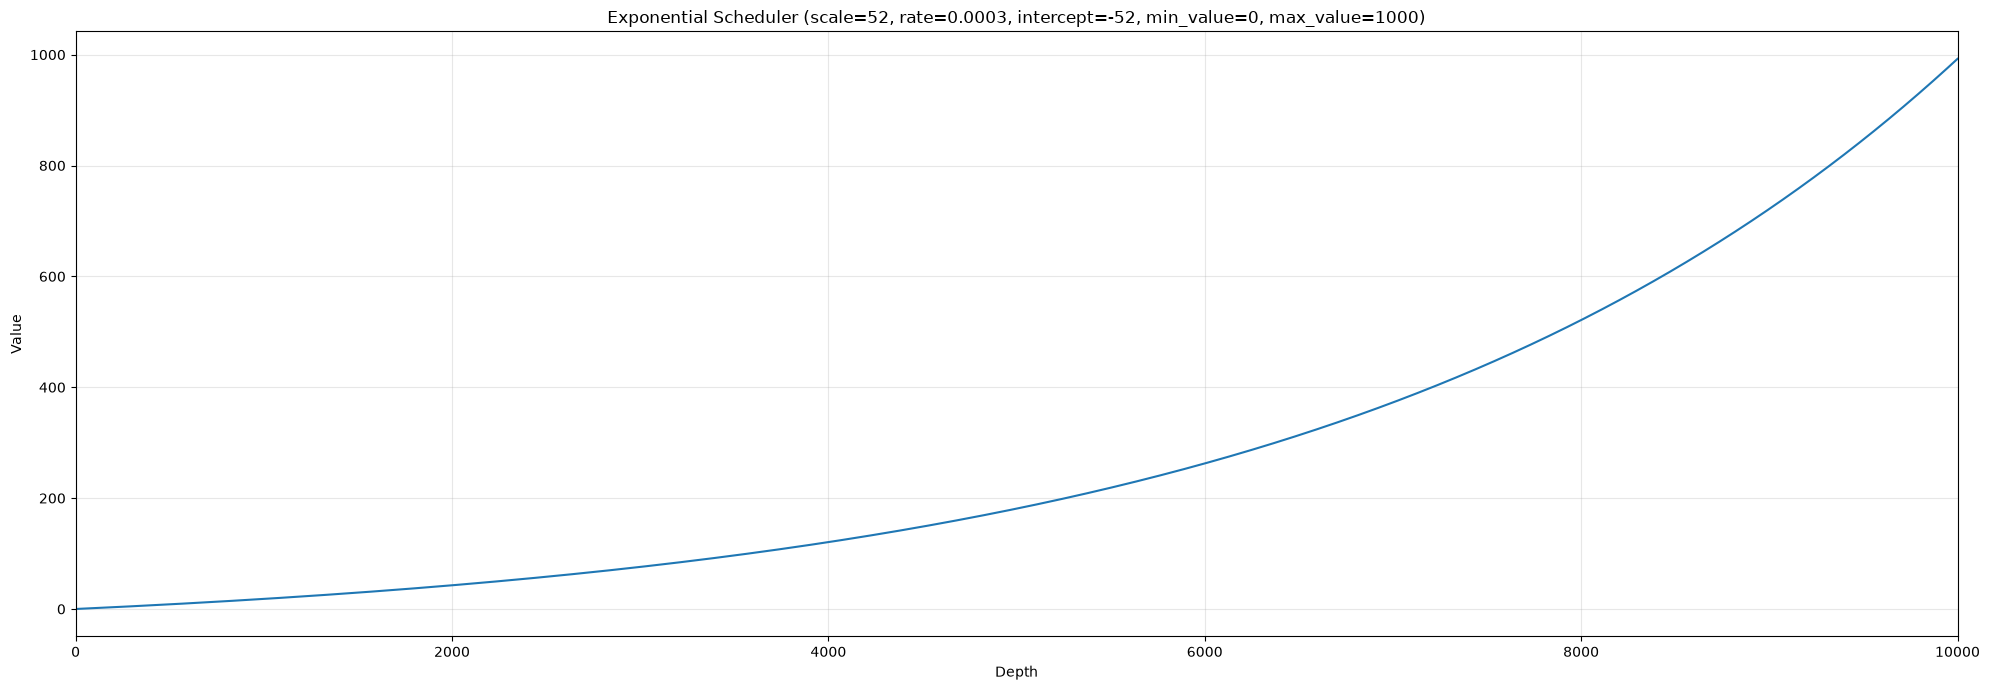

In [5]:
# plot the scheduler
fig, ax = plt.subplots(figsize=(20, 7))
plot_scheduler(ax, scheduler)
fig.tight_layout()
plt.show()

## Conclusions

This playground provides an empirical view of how an `ExponentialScheduler` maps depth to a value whose rate of change increases with depth. The configured scale, rate, and intercept determine the shape and position of the exponential relationship, while the minimum and maximum values constrain the resulting schedule.

Examined in isolation, the module exhibits its intended behavior: it implements a bounded exponential scheduling strategy in which the scheduled value grows at an increasing rate across depth.